In [1]:
import pandas as pd
import numpy as np
from datetime import timedelta
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy

In [2]:
# Función para graficar
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, shade=True, snk=False):
    skewness = (data[column]).skew()
    kurtosis = (data[column]).kurt()
    media = (data[column]).mean()
    var = (data[column]).var()
    std = (data[column]).std()
    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde)
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
        plt.axvline(media, color='red', linestyle='--', label='Media')
 

    # Sombreado
    if mvd and shade:
        plt.axvspan(media - std, media + std, alpha=0.1, color='orange', label='±1 Std')
        plt.axvline(media + std, color='orange', linestyle=':', label='+1 Std')
        plt.axvline(media - std, color='orange', linestyle=':', label='-1 Std')
        plt.figtext(0.15, 0.80, f'Media: {media:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.73, f'Var:   {var:.2f}',   fontsize=10, color='red')
        plt.figtext(0.15, 0.66, f'Std:   {std:.2f}',   fontsize=10, color='orange')

    

    plt.title(f'Variable: {column}')
    plt.xlabel(f'{column}')
    plt.ylabel('Frecuencia')
    plt.show()
    
    return

In [3]:
def plot_frecuencias_relativas(data, column, ax=None, palette='viridis', figsize=(9, 4), title=None):
    total = len(data)
    relative_freq = data[column].value_counts() / total

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(x=relative_freq.values, y=relative_freq.index, hue=relative_freq.index, 
                palette=palette, ax=ax, legend=False)
    
    ax.set_title(title if title else f'Frecuencias relativas de {column}')
    ax.set_xlabel('Frecuencia relativa')
    ax.set_ylabel(column)

plt.show()

In [4]:
def plot_violin_box(data, num_col, cat_col, figsize=(12, 4), palette='pastel', title=None):
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    # Violin plot
    sns.violinplot(data=data, x=cat_col, y=num_col, hue=cat_col,
                   palette=palette, ax=axes[0], legend=False)
    axes[0].set_title(f'Violin: {num_col} vs. {cat_col}')
    axes[0].grid(axis='y', ls='--')

    # Box plot
    sns.boxplot(data=data, x=cat_col, y=num_col, hue=cat_col,
                palette=palette, ax=axes[1], legend=False)
    axes[1].set_title(f'Boxplot: {num_col} vs. {cat_col}')
    axes[1].grid(axis='y', ls='--')

    plt.suptitle(title if title else f'{num_col} vs {cat_col}', fontsize=13)
    plt.tight_layout()
    plt.show()

In [5]:
penguins_df = pd.read_csv('../Actividad 2 (Opcional)/penguins_lter.csv')

In [ ]:
# Conversión de variables categóricas a "category"
columnas_categoricas = ['Species', 'Island', 'Stage', 'Sex', 'Clutch Completion']
for columna in columnas_categoricas:
    penguins_df[columna] = penguins_df[columna].astype('category')

print(f"Dimensiones del dataset: {penguins_df.shape}")
print("\nInformación de tipos y nulos:")
penguins_df.info()

Dimensiones del dataset: (344, 17)

Información de tipos y nulos:
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   studyName            344 non-null    str     
 1   Sample Number        344 non-null    int64   
 2   Species              344 non-null    category
 3   Region               344 non-null    str     
 4   Island               344 non-null    category
 5   Stage                344 non-null    category
 6   Individual ID        344 non-null    str     
 7   Clutch Completion    344 non-null    category
 8   Date Egg             344 non-null    str     
 9   Culmen Length (mm)   342 non-null    float64 
 10  Culmen Depth (mm)    342 non-null    float64 
 11  Flipper Length (mm)  342 non-null    float64 
 12  Body Mass (g)        342 non-null    float64 
 13  Sex                  334 non-null    category
 14  Delta 15 N (o/oo)  

In [7]:
# 2. EXPLORACION DE VARIABLES CATEGORICAS Y ENTROPIA
print("\n--- RESUMEN CATEGORICO ---")
display(penguins_df.describe(include=['category', 'bool']))


--- RESUMEN CATEGORICO ---


,Species,Island,Stage,Clutch Completion,Sex
count,344,344,344,344,334
unique,3,3,1,2,3
top,Adelie Penguin (Pygoscelis adeliae),Biscoe,"Adult, 1 Egg Stage",Yes,MALE
freq,152,168,344,308,168


In [ ]:
# Calculo de Entropia de Shannon para 'Species'
species_counts = penguins_df['Species'].value_counts()
species_probs = species_counts / species_counts.sum()
H_max = np.log2(penguins_df['Species'].nunique())
H_shannon = entropy(species_probs, base=2)

print(f"\nEntropía Species: {H_shannon:.2f} | Entropía máxima H_max: {H_max:.2f}")


Entropía Species: 1.51 | Entropía máxima H_max: 1.58


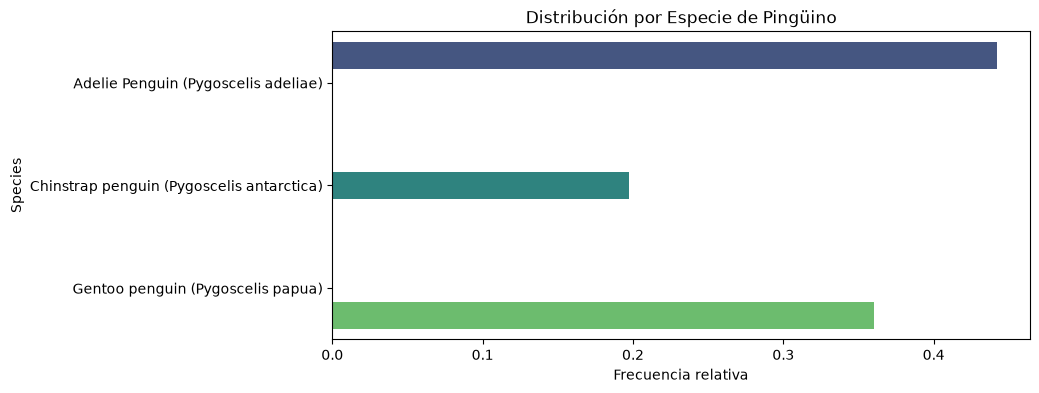

In [9]:
# Gráfico de frecuencias categóricas
plot_frecuencias_relativas(penguins_df, 'Species', title='Distribución por Especie de Pingüino')

In [3]:
# 3. ANALISIS DE DATOS FALTANTES (MISSINGNO)
if 'pd' not in globals():
    import pandas as pd
if 'penguins_df' not in globals():
    penguins_df = pd.read_csv('../Actividad 2 (Opcional)/penguins_lter.csv')

print("\n--- ANALISIS DE DATOS FALTANTES ---")
faltantes = penguins_df.isna().sum()
faltantes_df = pd.DataFrame({
    'faltantes': faltantes,
    'porcentaje': (faltantes / len(penguins_df) * 100).round(2)
})
print(faltantes_df[faltantes_df['faltantes'] > 0])


--- ANALISIS DE DATOS FALTANTES ---
                     faltantes  porcentaje
Culmen Length (mm)           2        0.58
Culmen Depth (mm)            2        0.58
Flipper Length (mm)          2        0.58
Body Mass (g)                2        0.58
Sex                         10        2.91
Delta 15 N (o/oo)           14        4.07
Delta 13 C (o/oo)           13        3.78
Comments                   318       92.44


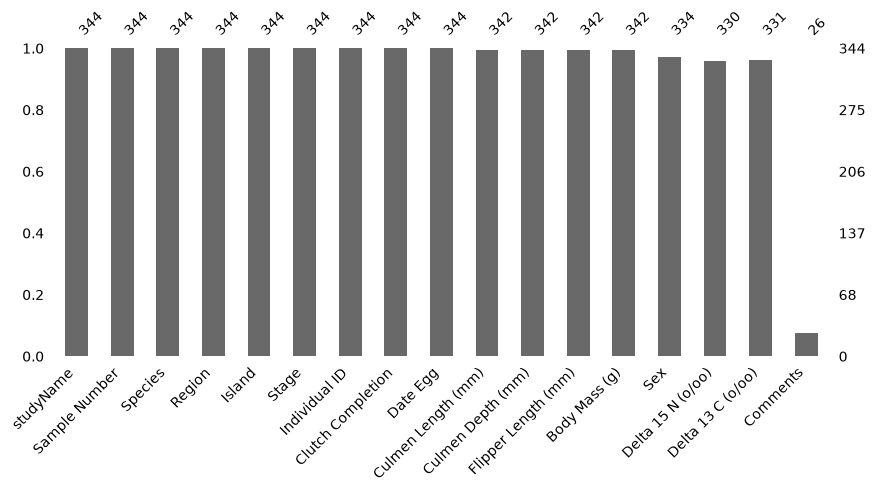

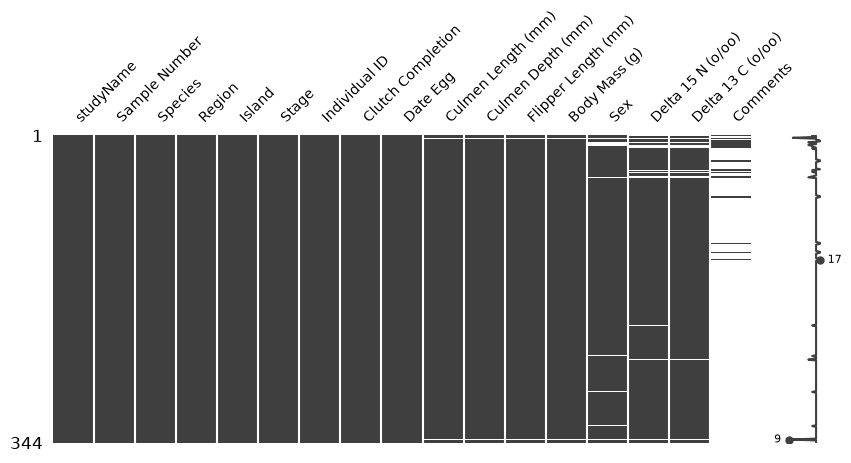

In [ ]:
# Matriz y barra de valores nulos
if 'msno' not in globals():
    import missingno as msno
if 'plt' not in globals():
    import matplotlib.pyplot as plt

msno.bar(penguins_df, figsize=(10, 4), fontsize=10)
plt.show()

msno.matrix(penguins_df, figsize=(10, 4), fontsize=10)
plt.show()

In [12]:
# Porcentaje de valores faltantes en Sex por especie
def nulos_por_grupo(df, grupo_cols, target_col):
    return df.groupby(grupo_cols, observed=True)[target_col].apply(lambda x: x.isnull().mean() * 100).reset_index(name='pct_nulos')

print("\nPorcentaje de valores faltantes en Sex por especie:")
display(nulos_por_grupo(penguins_df, ['Species'], 'Sex'))


Porcentaje de valores faltantes en Sex por especie:


,Species,pct_nulos
0,Adelie Penguin (Pygoscelis adeliae),3.947368
1,Chinstrap penguin (Pygoscelis antarctica),0.000000
2,Gentoo penguin (Pygoscelis papua),3.225806


In [13]:
# 4. ESTADÍSTICA DESCRIPTIVA DE VARIABLES NUMÉRICAS
columnas_numericas = [
    'Sample Number',
    'Culmen Length (mm)',
    'Culmen Depth (mm)',
    'Flipper Length (mm)',
    'Body Mass (g)',
    'Delta 15 N (o/oo)',
    'Delta 13 C (o/oo)'
]

ed_penguins = penguins_df[columnas_numericas].describe().T
ed_penguins = ed_penguins.rename(columns={
    'count': 'Observaciones',
    'min': 'Mínimo',
    'max': 'Máximo',
    'mean': 'Media',
    'std': 'Desvío estándar'
})

print("\nEstadística descriptiva de las variables numéricas:")
display(ed_penguins)


Estadística descriptiva de las variables numéricas:


,Observaciones,Media,Desvío estándar,Mínimo,25%,50%,75%,Máximo
Sample Number,344.0,63.151163,40.430199,1.00000,29.000000,58.000000,95.250000,152.00000
Culmen Length (mm),342.0,43.921930,5.459584,32.10000,39.225000,44.450000,48.500000,59.60000
Culmen Depth (mm),342.0,17.151170,1.974793,13.10000,15.600000,17.300000,18.700000,21.50000
Flipper Length (mm),342.0,200.915205,14.061714,172.00000,190.000000,197.000000,213.000000,231.00000
Body Mass (g),342.0,4201.754386,801.954536,2700.00000,3550.000000,4050.000000,4750.000000,6300.00000
Delta 15 N (o/oo),330.0,8.733382,0.551770,7.63220,8.299890,8.652405,9.172123,10.02544
Delta 13 C (o/oo),331.0,-25.686292,0.793961,-27.01854,-26.320305,-25.833520,-25.062050,-23.78767


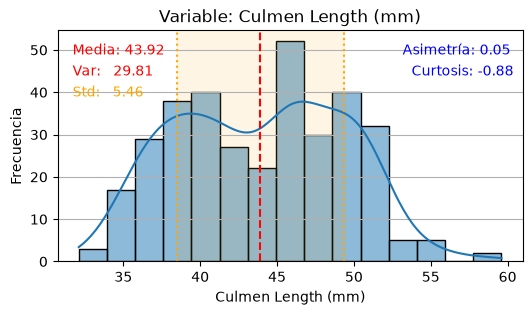

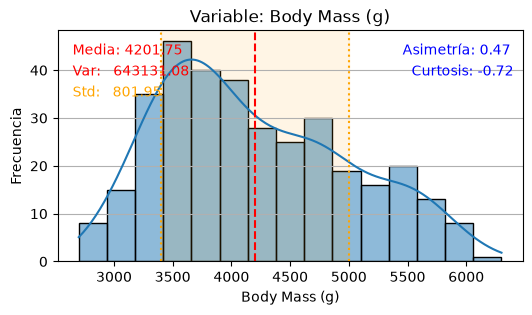

In [14]:
# Histogramas de variables numéricas relevantes
plot_histograma(penguins_df, 'Culmen Length (mm)', snk=True)
plot_histograma(penguins_df, 'Body Mass (g)', snk=True)

In [15]:
# 5. DETECCIÓN Y ANÁLISIS DE OUTLIERS
# Método de rango intercuartil para detectar outliers
cols_outliers = [
    'Culmen Length (mm)',
    'Culmen Depth (mm)',
    'Flipper Length (mm)',
    'Body Mass (g)'
]
datos_outliers = penguins_df[cols_outliers]
Q1 = datos_outliers.quantile(0.25)
Q3 = datos_outliers.quantile(0.75)
IQR = Q3 - Q1

limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

print("\n--- OUTLIERS DETECTADOS (MÉTODO IQR) ---")
for col in cols_outliers:
    outliers = penguins_df[(penguins_df[col] < limite_inf[col]) | (penguins_df[col] > limite_sup[col])]
    print(f"{col}: {len(outliers)} outliers identificados")


--- OUTLIERS DETECTADOS (MÉTODO IQR) ---
Culmen Length (mm): 0 outliers identificados
Culmen Depth (mm): 0 outliers identificados
Flipper Length (mm): 0 outliers identificados
Body Mass (g): 0 outliers identificados


In [16]:
# Método de regla de 3 desviaciones estándar (3 SD)
media = datos_outliers.mean()
desvio = datos_outliers.std()
outliers_3sd = (datos_outliers < (media - 3 * desvio)) | (datos_outliers > (media + 3 * desvio))

print(f"\nTotal de filas con al menos un valor extremo (|Z| > 3): {outliers_3sd.any(axis=1).sum()}")


Total de filas con al menos un valor extremo (|Z| > 3): 0


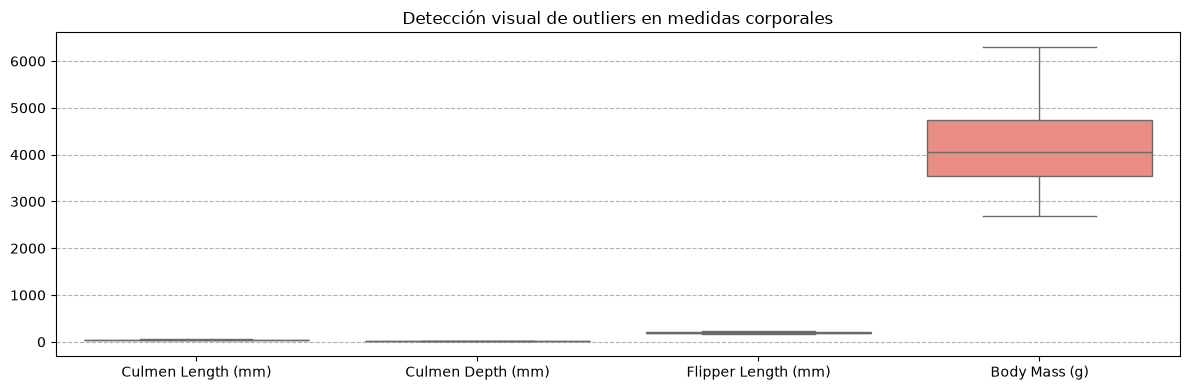

In [ ]:
# Visualización de boxplots de las variables numéricas
plt.figure(figsize=(12, 4))
sns.boxplot(data=penguins_df[cols_outliers], palette='Set3')
plt.title('Detección visual de outliers en medidas corporales')
plt.grid(axis='y', ls='--')
plt.tight_layout()
plt.show()

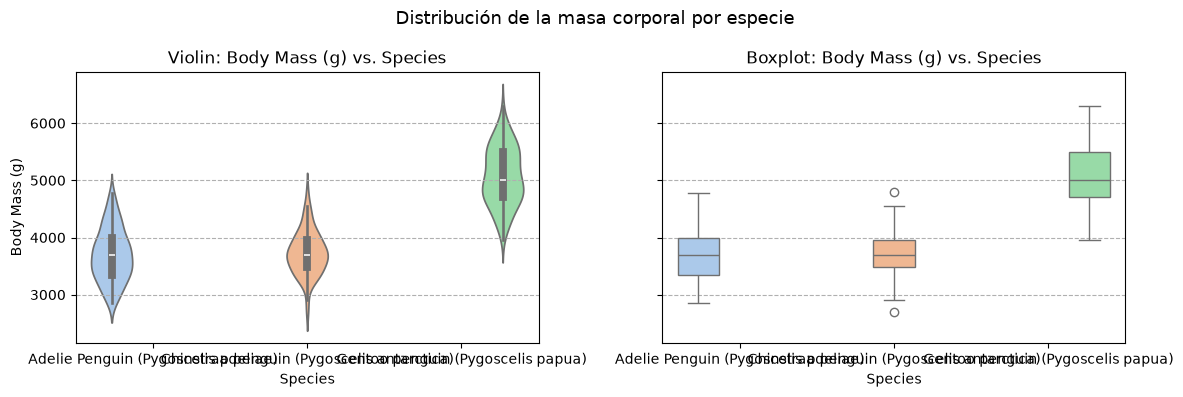

In [18]:
# 6. RELACIONES ENTRE VARIABLES
# Numérica-Categórica: Violin y Boxplot
plot_violin_box(
    penguins_df,
    num_col='Body Mass (g)',
    cat_col='Species',
    title='Distribución de la masa corporal por especie'
)

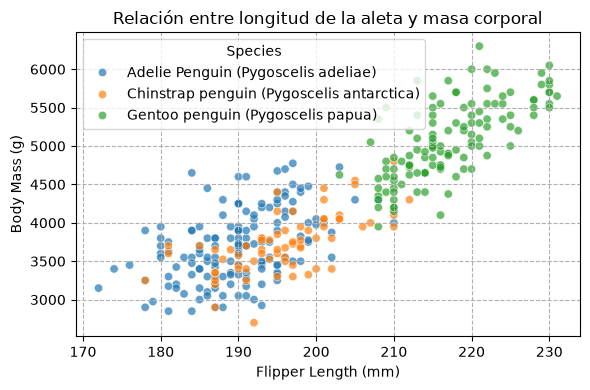

In [19]:
# Numérica-Numérica: Scatterplot
plt.figure(figsize=(6, 4))
sns.scatterplot(data=penguins_df, x='Flipper Length (mm)', y='Body Mass (g)', hue='Species', alpha=0.7)
plt.grid(ls='--')
plt.title('Relación entre longitud de la aleta y masa corporal')
plt.tight_layout()
plt.show()

# Permite observar si los pingüinos con aletas más largas tienden a tener mayor masa corporal.

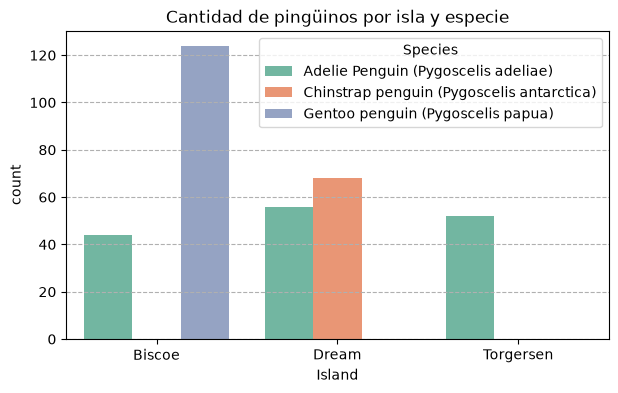

In [20]:
# Categórica-Categórica: Gráfico de barras
plt.figure(figsize=(7, 4))
sns.countplot(x='Island', hue='Species', data=penguins_df, palette='Set2')
plt.grid(ls='--', axis='y')
plt.title("Cantidad de pingüinos por isla y especie")
plt.show()

# Permite observar cómo se distribuyen las especies entre las islas estudiadas.